In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.optimize import minimize

from rich import print
import seaborn as sns
sns.set()

import ewatercycle
import ewatercycle.models
import ewatercycle.forcing
from scipy.stats import qmc
from ipywidgets import IntProgress

In [2]:
calibration_start_date = "1975-01-01"
calibration_end_date = "2010-12-31"

In [3]:
forcing_path_ERA5 = Path.home() / "BEP-beau/BEP/code" / "CatchmentArea" / "ERA5" / "own_shapefile"
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

data = pd.read_csv("mohembo_daily_water_discharge_data.csv", index_col='date', parse_dates=True, dayfirst=True)
data_daily = data.resample('D').interpolate()
data_daily.columns = ['Discharge (m^3/s)']

In [4]:
Area_km2 = 173696.852

def mmday_to_m3s(mmday_data, area):
    return (mmday_data * area) / 86.4

In [13]:
def logNSE(modelled, observed, start, end):
    start = pd.to_datetime(start).tz_localize(None)
    end = pd.to_datetime(end).tz_localize(None)
    
    modelled.index = pd.to_datetime(modelled.index)
    observed.index = pd.to_datetime(observed.index)

    df = pd.concat([modelled.reindex(observed.index, method='ffill'), observed], axis=1, keys=['Modelled', 'Observed'])
    df = df.dropna()
    df = df[(df.index > start) & (df.index < end)]

    a = (np.log(df['Modelled']) - np.log(df['Observed']))**2
    a1 = a.sum() 
    b = (np.log(df['Observed']) - np.log(np.mean(df['Observed'])))**2
    b1 = b.sum()
    lognse = 1 - (a1/b1)
    return lognse

In [34]:
N = 2000
s_0 = np.array([0,  100,  0,  5,  0])

param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "FM"]
param_mins = np.array([0, 0.2, 250, 0.5, 0.001, 1, 0.0005, 0.00005, 0.00001])
param_maxs = np.array([8, 1.5, 2500, 4, 0.3, 90, 0.1, 0.002, 1])

sampler = qmc.LatinHypercube(d=len(param_names))
sample = sampler.random(n=N)
parameters = qmc.scale(sample, param_mins, param_maxs)

In [35]:
ensemble = []

for counter in range(N): 
    ensemble.append(ewatercycle.models.HBVLocal(forcing=ERA5_forcing))
    config_file, _ = ensemble[counter].setup(parameters = parameters[counter],  initial_storage=s_0)
    ensemble[counter].initialize(config_file)

In [36]:
f = IntProgress(min=0, max=N)
display(f)

NSE_values = []
for ensembleMember in ensemble:
    Q_m_NSE = []
    time_NSE = []
    while ensembleMember.time < ensembleMember.end_time:
        ensembleMember.update()
        discharge_this_timestep = ensembleMember.get_value("Q")
        Q_m_NSE.append(discharge_this_timestep[0])
        time_NSE.append(ensembleMember.time_as_datetime)

    Q_m_NSE = mmday_to_m3s(np.array(Q_m_NSE), Area_km2)
    discharge_dataframe = pd.DataFrame({'model output': Q_m_NSE}, index=pd.to_datetime(time_NSE))

    nsevalue = logNSE(discharge_dataframe['model output'], data_daily['Discharge (m^3/s)'], calibration_start_date, calibration_end_date)
    NSE_values.append(nsevalue)
    
    del Q_m_NSE, time_NSE, discharge_dataframe, nsevalue
    f.value += 1
    
for ensembleMember in ensemble:
    ensembleMember.finalize()

IntProgress(value=0, max=2000)

In [53]:
best_index = np.argmax(NSE_values)
best_parameters = parameters[best_index]
best_NSE = NSE_values[best_index]
print(list(zip(param_names, np.round(best_parameters, decimals=3))))
print(f"Best NSE: {best_NSE:.3f}")
best_parameters

[
    ('Imax', 7.116),
    ('Ce', 0.355),
    ('Sumax', 1668.678),
    ('Beta', 2.525),
    ('Pmax', 0.284),
    ('Tlag', 21.84),
    ('Kf', 0.044),
    ('Ks', 0.002),
    ('FM', 0.786)
]

Best NSE: 0.355

array([7.11582486e+00, 3.55465549e-01, 1.66867785e+03, 2.52511916e+00,
       2.83558319e-01, 2.18402436e+01, 4.37905219e-02, 1.74426784e-03,
       7.85849656e-01])

In [38]:
s_0 = np.array([0,  100,  0,  5,  0])

In [39]:
forcing_path_ERA5 = Path.home() / "BEP-beau/BEP/code" / "CatchmentArea" / "ERA5_1" / "own_shapefile_1"
load_location = forcing_path_ERA5 / "work" / "diagnostic" / "script"  
ERA5_forcing1 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)
model = ewatercycle.models.HBV(forcing=ERA5_forcing1)

In [40]:
config_file, _ = model.setup(parameters=best_parameters, initial_storage=s_0)

In [41]:
model.initialize(config_file)

In [42]:
Q_m = []
time = []
while model.time < model.end_time:
    model.update()
    Q_m.append(model.get_value("Q")[0])
    time.append(pd.Timestamp(model.time_as_datetime))

In [43]:
model.finalize()

In [44]:
model_output = pd.Series(data=Q_m, name="Modelled_discharge", index=time)

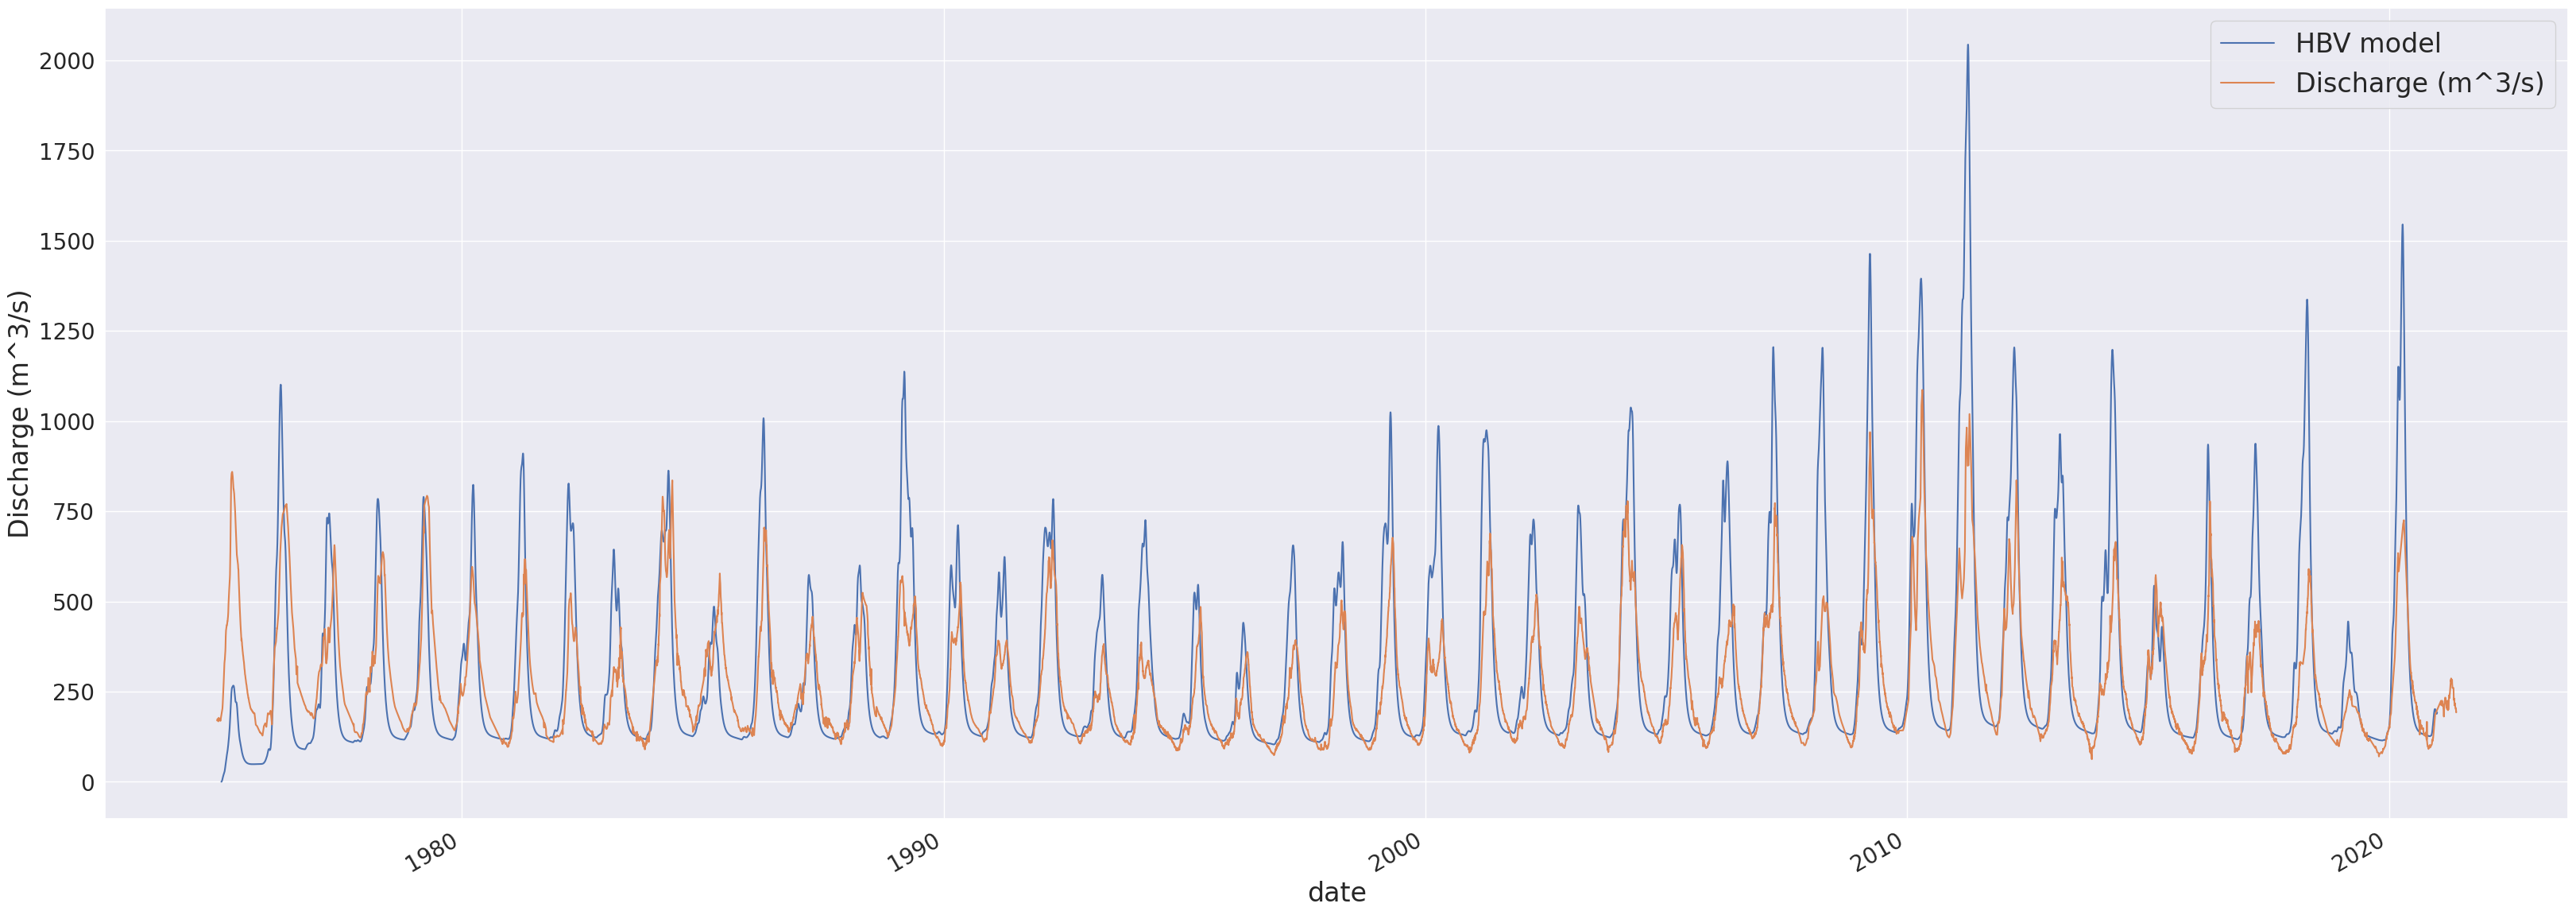

In [45]:
Q_model = mmday_to_m3s(model_output.values, Area_km2)
Q_model_pd = pd.Series(Q_model, index=model_output.index, name="HBV model")

fig, ax = plt.subplots(figsize=(40, 15))
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlabel("Date", fontsize=24)
ax.set_ylabel("Discharge (m^3/s)", fontsize=24)
Q_model_pd.plot(ax=ax)
data_daily.plot(ax=ax)
plt.legend(fontsize=24)
plt.ylabel("Discharge (m^3/s)");

In [55]:
start_validation = "2011-01-01"
end_validation = "2020-12-31"

nse_validation = logNSE(Q_model_pd, data_daily['Discharge (m^3/s)'], start_validation, end_validation)
print(nse_validation)

0.6654114034092911

In [56]:
start = "1975-01-01"
end = "2020-12-31"

nse_total = logNSE(Q_model_pd, data_daily['Discharge (m^3/s)'], start, end)
print(nse_total)

0.43675445693526904